# DATA 620 Final Project
## NBA Trade Network and Public Sentiment Analysis

**Course:** DATA 620 Web Analytics
**Instructor:** Professor Alain Ledon

## Group Members
- Crystal Quezada — Data Sourcing and Feature Engineering
- Nana Kwasi Danquah — Network Construction and Topological Metrics
- Muhammad Suffyan Khan — Natural Language Processing and Thematic Text Analysis

## Project Purpose
This project examines the NBA trade ecosystem during the **2025-26 season and the 2026 offseason**, with a documented data collection **cutoff date of July 10, 2026**. A directed network represents completed player movements, with teams serving as nodes and each movement acting as a directed edge connecting the sending and receiving teams. Following that, we examine public opinion and sports media narratives surrounding a few key trades, comparing them to the teams and transactions that the network considers structurally significant.

## Research Questions
1. Which NBA teams are the most central in the 2025–26 season and 2026 offseason trade network based on in-degree, out-degree, weighted in-degree, weighted out-degree, and betweenness centrality?
2. How do transaction volume and player salary movement relate to a team's structural position within the trade network?
3. What sentiments and recurring themes appear in public commentary and sports coverage surrounding selected major NBA trades?
4. How do these public narratives compare with the teams and transactions identified as important through the network analysis?


## Data and Methods Notes

**Trade data.** The transaction log ('nba_trades_2025_26.csv') was compiled using the official NBA.com trade trackers for the 2025-26 season and the 2026 offseason, as well as team press releases linked from those trackers. The list only includes trades that have been officially approved by the league and announced by the teams. Each row represents a single **player movement**; multi-team trades are decomposed into directed player-movement edges that share a 'trade_id', ensuring that all movements remain linked to the original transaction. Draft-pick-only trades from the 2026 Draft are excluded because there is no player (roster) movement; however, one draft-rights movement embedded in a player trade is retained and identified with'movement_type = draft_rights'.

**Salary data.** 'salary_est_musd' represents the estimated 2025-26 cap hit in millions of dollars. These values are estimates based on public contract information and are marked in the'salary_verified' column as pending verification with Spotrac, as described in our proposal ("document any missing or estimated values"). Per-game performance statistics are a planned extension of the 'nba_api' package that is not required for the following analyses.

**Text corpus.** 'corpus_major_trades.csv' contains twelve documents that cover the selected major trades (the James Harden, Anthony Davis, Trae Young, and Deandre Ayton transactions). Each document is a brief team-written summary of a real, publicly available article or fan-survey report, with the outlet, publication date, and URL preserved so that results can be verified and the summaries can be replaced or supplemented with full article text and Reddit comments (e.g., via PRAW) in an expanded corpus. Sentiment and thematic results are therefore evaluated at the document level and validated by manual review, in accordance with the proposals.

**Tools.** The team reviewed Python with 'pandas', 'NetworkX', 'Matplotlib', 'vaderSentiment', and'scikit-learn'; all sources can be found in the References section.


In [14]:
# Environment setup — installs the one dependency not bundled with Anaconda/Colab.
# Safe to re-run; does nothing if already installed.
%pip install -q vaderSentiment

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print('pandas', pd.__version__, '| networkx', nx.__version__)

pandas 2.3.3 | networkx 3.5


---
# Part 1 — Transaction Log: Loading, Cleaning and Structure
*(Component lead: Crystal Quezada)*

We load the compiled transaction log, standardize team identifiers, look for anomalies, and summarize the data.

In [16]:
DATA_URL = 'https://raw.githubusercontent.com/suffyankhan77/DATA620-Web-Analytics/refs/heads/main/projects/final_project/'
trades = pd.read_csv(DATA_URL + 'nba_trades_2025_26.csv', parse_dates=['trade_date'])

TEAM_NAMES = {
 'ATL':'Atlanta Hawks','BOS':'Boston Celtics','BKN':'Brooklyn Nets','CHA':'Charlotte Hornets',
 'CHI':'Chicago Bulls','CLE':'Cleveland Cavaliers','DAL':'Dallas Mavericks','DEN':'Denver Nuggets',
 'DET':'Detroit Pistons','GSW':'Golden State Warriors','HOU':'Houston Rockets','IND':'Indiana Pacers',
 'LAC':'LA Clippers','LAL':'Los Angeles Lakers','MEM':'Memphis Grizzlies','MIA':'Miami Heat',
 'MIL':'Milwaukee Bucks','MIN':'Minnesota Timberwolves','NOP':'New Orleans Pelicans','NYK':'New York Knicks',
 'OKC':'Oklahoma City Thunder','ORL':'Orlando Magic','PHI':'Philadelphia 76ers','PHX':'Phoenix Suns',
 'POR':'Portland Trail Blazers','SAC':'Sacramento Kings','SAS':'San Antonio Spurs','TOR':'Toronto Raptors',
 'UTA':'Utah Jazz','WAS':'Washington Wizards'}

# --- Cleaning and validation checks ---
assert trades['from_team'].isin(TEAM_NAMES).all(), 'Unknown origin team code'
assert trades['to_team'].isin(TEAM_NAMES).all(),   'Unknown destination team code'
assert (trades['from_team'] != trades['to_team']).all(), 'Self-loop found'
assert trades['salary_est_musd'].ge(0).all(), 'Negative salary'
dupes = trades.duplicated(subset=['trade_id','player','from_team','to_team']).sum()
print('Duplicate movement rows:', dupes)

print(f"{len(trades)} player movements across {trades.trade_id.nunique()} official trades")
print(f"Date range: {trades.trade_date.min().date()} to {trades.trade_date.max().date()} (cutoff 2026-07-10)")
trades.head(8)

Duplicate movement rows: 0
77 player movements across 27 official trades
Date range: 2026-01-09 to 2026-07-07 (cutoff 2026-07-10)


,trade_id,trade_date,season_phase,player,from_team,to_team,salary_est_musd,movement_type,salary_verified
0,T01,2026-01-09,2025-26 season,Trae Young,ATL,WAS,46.0,player,no (estimate — verify vs Spotrac)
1,T01,2026-01-09,2025-26 season,CJ McCollum,WAS,ATL,30.7,player,no (estimate — verify vs Spotrac)
2,T01,2026-01-09,2025-26 season,Corey Kispert,WAS,ATL,13.9,player,no (estimate — verify vs Spotrac)
3,T02,2026-02-01,2025-26 season,Vit Krejci,ATL,POR,2.2,player,no (estimate — verify vs Spotrac)
4,T02,2026-02-01,2025-26 season,Duop Reath,POR,ATL,2.2,player,no (estimate — verify vs Spotrac)
5,T03,2026-02-01,2025-26 season,Keon Ellis,SAC,CLE,2.3,player,no (estimate — verify vs Spotrac)
6,T03,2026-02-01,2025-26 season,Dennis Schroder,SAC,CLE,14.1,player,no (estimate — verify vs Spotrac)
7,T03,2026-02-01,2025-26 season,Emanuel Miller,CHI,CLE,1.9,player,no (estimate — verify vs Spotrac)


In [17]:
# Dataset structure and summary
print(trades['season_phase'].value_counts().to_string(), '\n')
print(trades['movement_type'].value_counts().to_string(), '\n')

# Multi-team trades: movements per trade
mv_per_trade = trades.groupby('trade_id').size().sort_values(ascending=False)
print('Movements per trade (top 6):')
print(mv_per_trade.head(6).to_string())

# Players who moved more than once within the window — a data-consistency
# check flagged in our proposal (they must appear as separate movements)
multi_movers = trades[trades.movement_type=='player'].groupby('player')['trade_id'].nunique()
print('\nPlayers traded more than once in the window:')
print(multi_movers[multi_movers > 1].to_string())

season_phase
2025-26 season    75
2026 offseason     2 

movement_type
player          76
draft_rights     1 

Movements per trade (top 6):
trade_id
T10    9
T04    8
T03    5
T15    5
T14    4
T05    4

Players traded more than once in the window:
player
Dalen Terry      2
Dario Saric      2
Jaden Hardy      2
Jock Landale     2
Mike Conley      2
Ousmane Dieng    3
Tyus Jones       2


**Observations.** The February 5, 2026 trade deadline dominates the window (19 out of 27 trades). The largest transaction is Anthony Davis' nine-player deal (T10). Three players moved multiple times inside the window, with Ousmane Dieng moving **three times in two days**, confirming the proposal's decision to store each movement as its own edge rather than collapsing by player.

---
# Part 2 — Directed Trade Network and Topological Metrics
*(Component lead: Nana Kwasi Danquah)*

Teams are nodes, and each player movement generates a directed edge **from the sending team to the receiving team**. We first create a 'MultiDiGraph' that preserves each movement (with edge attributes 'trade_id', player, and salary), then aggregate parallel edges into a weighted 'DiGraph' with two alternative edge weights: the **number of player movements** ('n_moves') and the **total salary value moved** ('salary').

In [18]:
# Player movements only for the core network (draft-rights row excluded)
pm = trades[trades.movement_type == 'player'].copy()

# Multigraph: every movement is its own edge
MG = nx.MultiDiGraph()
for _, r in pm.iterrows():
    MG.add_edge(r.from_team, r.to_team, trade_id=r.trade_id,
                player=r.player, salary=r.salary_est_musd, date=str(r.trade_date.date()))

# Aggregated weighted digraph
agg = (pm.groupby(['from_team','to_team'])
         .agg(n_moves=('player','size'), salary=('salary_est_musd','sum'))
         .reset_index())
G = nx.DiGraph()
for _, r in agg.iterrows():
    G.add_edge(r.from_team, r.to_team, n_moves=int(r.n_moves), salary=float(r.salary))

print(f'MultiDiGraph: {MG.number_of_nodes()} teams, {MG.number_of_edges()} movement edges')
print(f'Aggregated DiGraph: {G.number_of_nodes()} teams, {G.number_of_edges()} directed team-to-team links')
inactive = set(TEAM_NAMES) - set(G.nodes)
print('Teams with no completed trade in the window:', sorted(inactive) if inactive else 'none')

MultiDiGraph: 27 teams, 76 movement edges
Aggregated DiGraph: 27 teams, 53 directed team-to-team links
Teams with no completed trade in the window: ['HOU', 'MIA', 'SAS']


In [19]:
# --- Centrality measures (Research Question 1) ---
cent = pd.DataFrame(index=sorted(G.nodes))
cent['in_degree']      = pd.Series(dict(G.in_degree()))          # distinct sending partners
cent['out_degree']     = pd.Series(dict(G.out_degree()))         # distinct receiving partners
cent['w_in_moves']     = pd.Series(dict(G.in_degree(weight='n_moves')))   # players received
cent['w_out_moves']    = pd.Series(dict(G.out_degree(weight='n_moves')))  # players sent
cent['w_in_salary']    = pd.Series(dict(G.in_degree(weight='salary')))    # $M received
cent['w_out_salary']   = pd.Series(dict(G.out_degree(weight='salary')))   # $M sent

# Betweenness on the aggregated directed graph. For a weighted variant we use
# distance = 1/n_moves so that heavily-used trade channels are 'shorter'.
for u, v, d in G.edges(data=True):
    d['dist'] = 1.0 / d['n_moves']
cent['betweenness']    = pd.Series(nx.betweenness_centrality(G, normalized=True))
cent['betweenness_w']  = pd.Series(nx.betweenness_centrality(G, weight='dist', normalized=True))

cent['total_moves'] = cent.w_in_moves + cent.w_out_moves
cent['net_salary']  = (cent.w_in_salary - cent.w_out_salary).round(1)
cent = cent.fillna(0).round(3)

cent.sort_values('total_moves', ascending=False).head(12)

,in_degree,out_degree,w_in_moves,w_out_moves,w_in_salary,w_out_salary,betweenness,betweenness_w,total_moves,net_salary
CHI,7,7,10,10,100.5,93.9,0.524,0.520,20,6.6
WAS,3,4,6,7,130.1,98.2,0.215,0.257,13,31.9
ATL,5,4,7,4,98.0,89.9,0.218,0.215,11,8.1
CHA,5,3,6,4,46.0,37.0,0.328,0.367,10,9.0
UTA,2,2,5,5,61.4,35.7,0.147,0.108,10,25.7
MEM,2,1,5,4,31.2,51.4,0.010,0.010,9,-20.2
DAL,2,1,4,4,50.0,76.0,0.046,0.087,8,-26.0
LAC,2,3,3,4,55.8,63.6,0.089,0.089,7,-7.8
CLE,3,3,4,3,57.5,72.7,0.275,0.234,7,-15.2
MIN,1,1,2,3,10.3,19.7,0.000,0.000,5,-9.4


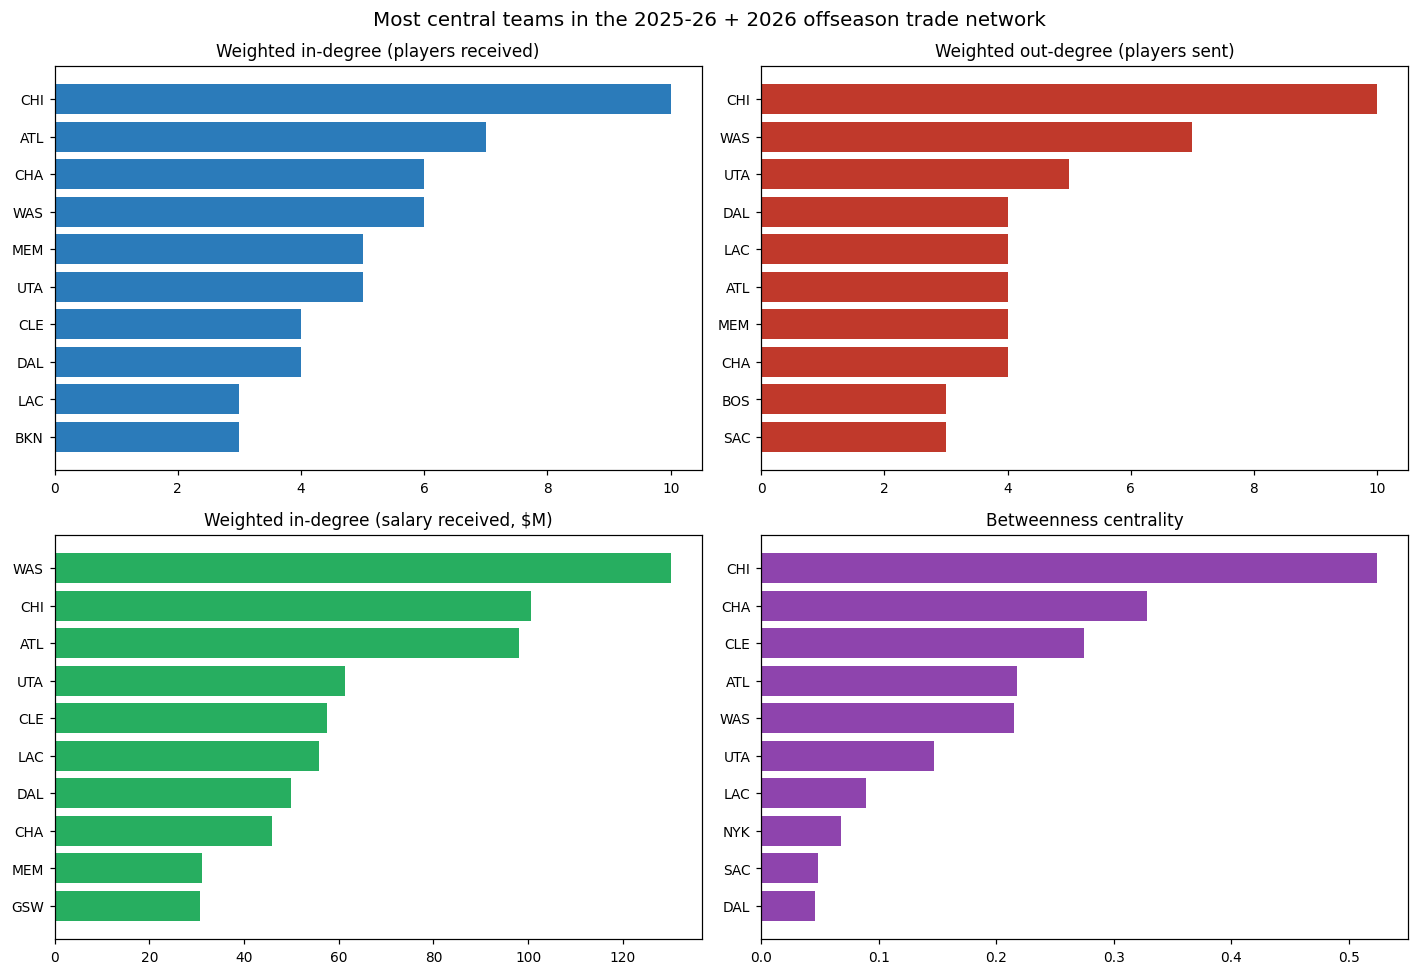

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
top = lambda col, n=10: cent[col].sort_values(ascending=False).head(n)

for ax, (col, title, color) in zip(axes.flat, [
        ('w_in_moves',  'Weighted in-degree (players received)',  '#2b7bba'),
        ('w_out_moves', 'Weighted out-degree (players sent)',      '#c0392b'),
        ('w_in_salary', 'Weighted in-degree (salary received, $M)','#27ae60'),
        ('betweenness', 'Betweenness centrality',                  '#8e44ad')]):
    s = top(col)
    ax.barh(s.index[::-1], s.values[::-1], color=color)
    ax.set_title(title, fontsize=11)
    ax.tick_params(labelsize=9)
fig.suptitle('Most central teams in the 2025-26 + 2026 offseason trade network', fontsize=13)
plt.tight_layout()
plt.show()

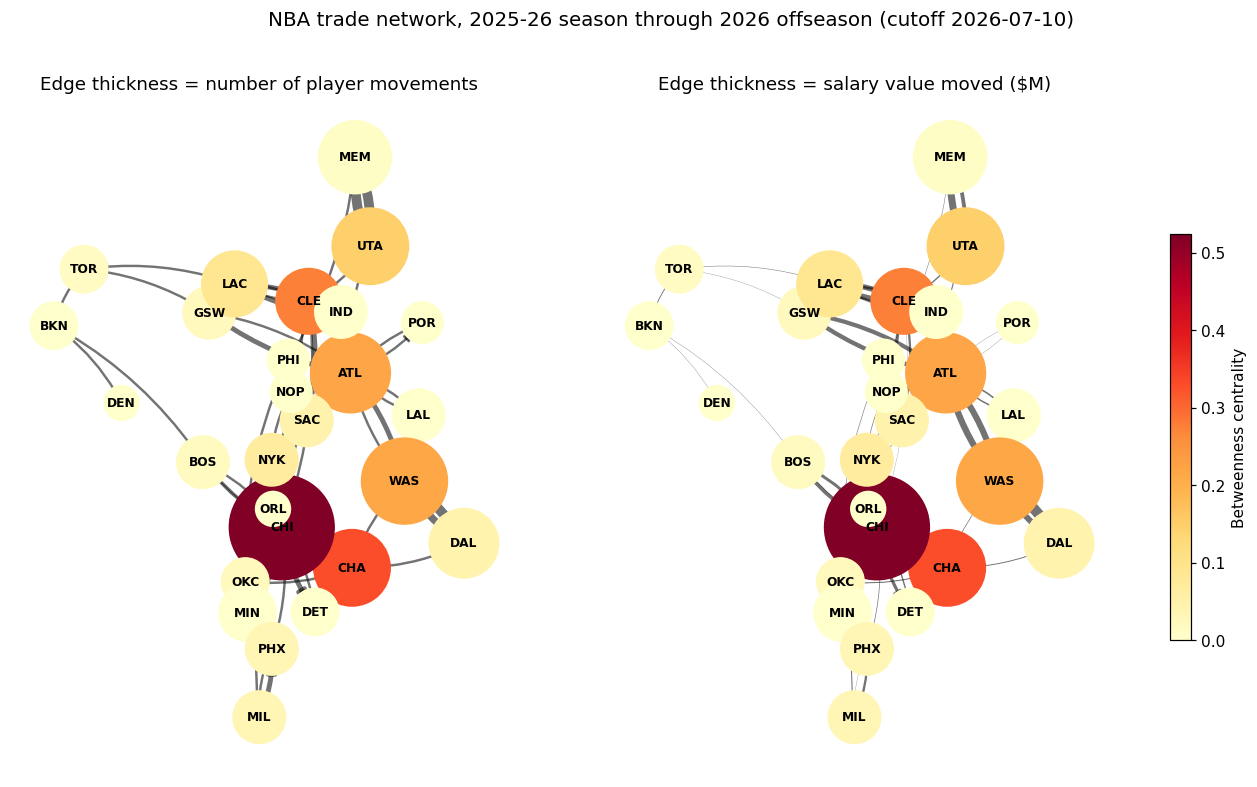

In [21]:
# --- Network visualization with edge thickness by trade activity ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
pos = nx.spring_layout(G, k=1.4, seed=620, iterations=200)

node_size = [300 + 220*cent.loc[n,'total_moves'] for n in G.nodes]
node_col  = [cent.loc[n,'betweenness'] for n in G.nodes]

for ax, wkey, title, scale in [(axes[0],'n_moves','Edge thickness = number of player movements',1.6),
                               (axes[1],'salary','Edge thickness = salary value moved ($M)',0.09)]:
    widths = [scale*d[wkey] for _,_,d in G.edges(data=True)]
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size,
                                   node_color=node_col, cmap='YlOrRd')
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.55,
                           arrowsize=11, connectionstyle='arc3,rad=0.12')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')
    ax.set_title(title); ax.axis('off')
fig.colorbar(nodes, ax=axes, shrink=0.6, label='Betweenness centrality')
plt.suptitle('NBA trade network, 2025-26 season through 2026 offseason (cutoff 2026-07-10)', fontsize=13)
plt.show()

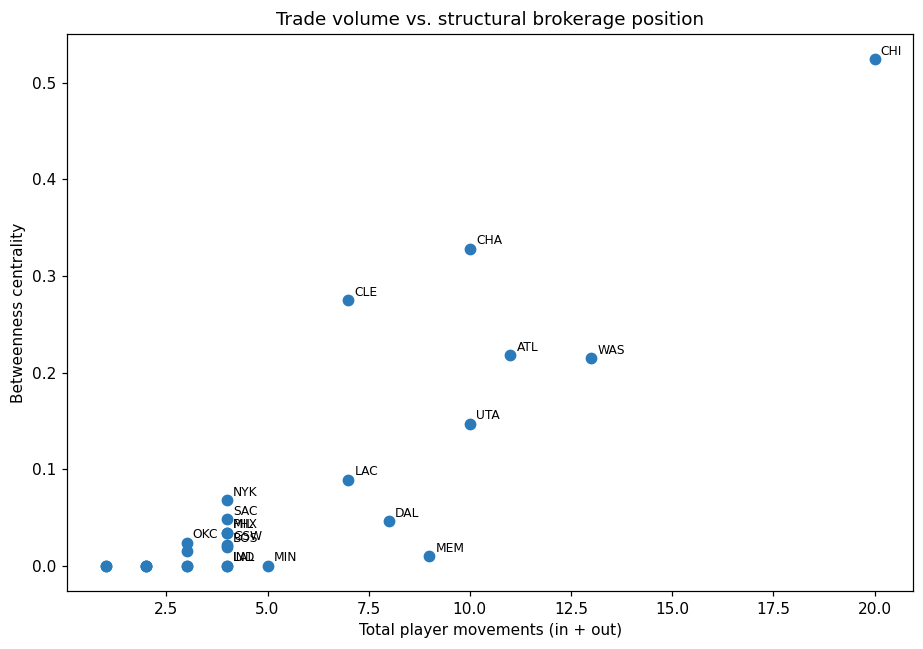

Spearman correlation, volume vs betweenness:        0.784
Spearman correlation, salary throughput vs betweenness: 0.763

Largest net salary importers ($M):
WAS    31.9
UTA    25.7
DET    13.3
BKN    11.2
PHX    10.0

Largest net salary exporters ($M):
DAL   -26.0
MEM   -20.2
CLE   -15.2
BOS   -11.2
MIN    -9.4


In [22]:
# --- RQ2: transaction volume and salary movement vs structural position ---
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(cent.total_moves, cent.betweenness, s=45, color='#2b7bba')
for t, r in cent.iterrows():
    if r.total_moves >= 4 or r.betweenness >= 0.02:
        ax.annotate(t, (r.total_moves, r.betweenness), fontsize=8,
                    xytext=(4, 3), textcoords='offset points')
ax.set_xlabel('Total player movements (in + out)')
ax.set_ylabel('Betweenness centrality')
ax.set_title('Trade volume vs. structural brokerage position')
plt.tight_layout(); plt.show()

corr1 = cent.total_moves.corr(cent.betweenness, method='spearman')
corr2 = (cent.w_in_salary + cent.w_out_salary).corr(cent.betweenness, method='spearman')
print(f'Spearman correlation, volume vs betweenness:        {corr1:.3f}')
print(f'Spearman correlation, salary throughput vs betweenness: {corr2:.3f}')
print('\nLargest net salary importers ($M):')
print(cent.net_salary.sort_values(ascending=False).head(5).to_string())
print('\nLargest net salary exporters ($M):')
print(cent.net_salary.sort_values().head(5).to_string())

**Network findings (RQ1 and RQ2).**

- **Chicago** is the runaway hub of the deadline network, appearing in six separate trades, leading the league in both players sent and received, and posting the highest betweenness centrality. The Bulls acted as the league's clearinghouse, recycling players (Conley, Šarić, Dieng, Terry) within days of acquiring them.
- **Washington** is the largest structural *importer* by salary ($130M+ received), driven by Anthony Davis and Trae Young blockbusters—its salary-weighted in-degree far outnumbers its movement count, demonstrating that salary weighting and volume weighting identify different types of hubs, exactly the contrast our proposal predicted. **Charlotte**, on the other hand, ranks second in betweenness due to its high volume of mid-salary movements. It is a broker rather than a destination.
- **Atlanta** is a broker, exporting stars like Young and Porziņģis and importing role players across four trades, resulting in high betweenness despite a negative net salary balance.
- Volume and betweenness are strongly, but not perfectly, correlated: high-volume teams tend to be on the shortest paths, whereas blockbuster teams like Dallas move enormous salaries through very few transactions.

---
# Part 3 — Public Sentiment and Thematic Text Analysis
*(Component lead: Muhammad Suffyan Khan)*

We examine a collection of documents from selected major trades. The pipeline includes text cleaning and tokenization, VADER sentiment scoring per document, trade aggregation, TF-IDF keyword extraction, and rule-based theme tagging for the proposal's identified recurring narratives (rebuilding, championship contention/win-now, salary-cap pressure, injury and durability).

In [23]:
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = pd.read_csv(DATA_URL + 'corpus_major_trades.csv')
print(f'{len(corpus)} documents | trades covered: {sorted(corpus.trade_id.unique())}')

def clean(t):
    t = t.lower()
    t = re.sub(r'[^a-z0-9\s\-]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

corpus['clean'] = corpus['text'].map(clean)
corpus['tokens'] = corpus['clean'].str.split()
print('Median document length (tokens):', int(corpus.tokens.str.len().median()))

sia = SentimentIntensityAnalyzer()
corpus['compound'] = corpus['text'].map(lambda t: sia.polarity_scores(t)['compound'])
corpus['sent_label'] = pd.cut(corpus['compound'], [-1, -0.05, 0.05, 1],
                              labels=['negative','neutral','positive'])
corpus[['doc_id','trade_focus','outlet','pub_date','compound','sent_label']]

12 documents | trades covered: ['T01', 'T06', 'T10', 'T27']
Median document length (tokens): 49


,doc_id,trade_focus,outlet,pub_date,compound,sent_label
0,D01,James Harden,Fear The Sword,2026-06-26,-0.8834,negative
1,D02,James Harden,SI / Cavaliers On SI,2026-03-04,0.8641,positive
2,D03,James Harden,King James Gospel,2026-04-27,-0.9231,negative
3,D04,James Harden,Fear The Sword,2026-06-20,0.5574,positive
4,D05,Anthony Davis,Bleacher Report,2026-06-25,-0.4215,negative
5,D06,Anthony Davis,ESPN,2026-07-09,0.5719,positive
6,D07,Anthony Davis,Yardbarker / EssentiallySports,2026-06-23,-0.2500,negative
7,D08,Anthony Davis,Bullets Forever,2026-06-27,-0.0258,neutral
8,D09,Trae Young,ESPN,2026-07-10,0.6249,positive
9,D10,Trae Young,Bleacher Report,2026-06-30,0.8588,positive


trade_id   trade_focus  docs  mean_compound  min_c  max_c
     T01    Trae Young     2          0.742  0.625  0.859
     T06  James Harden     5         -0.087 -0.923  0.864
     T10 Anthony Davis     4         -0.031 -0.422  0.572
     T27 Deandre Ayton     1          0.893  0.893  0.893


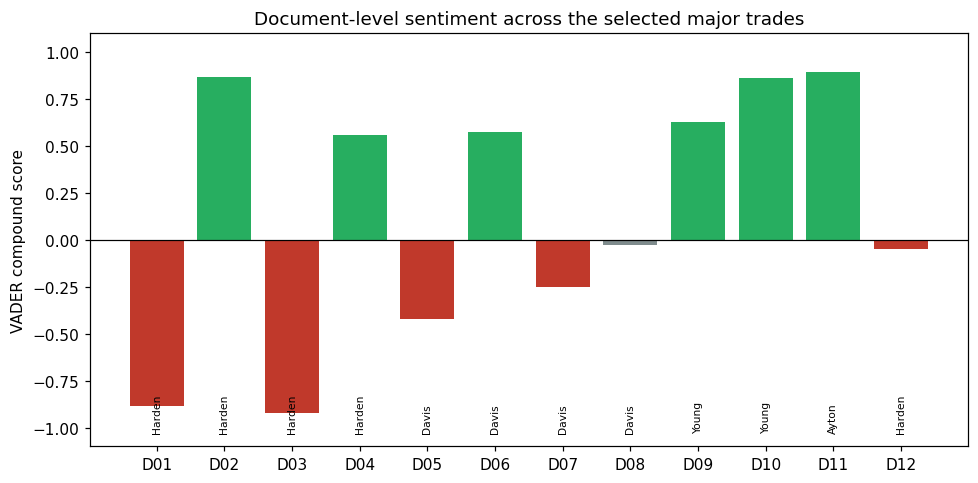

In [24]:
# Sentiment aggregated by trade
by_trade = (corpus.groupby(['trade_id','trade_focus'])
            .agg(docs=('doc_id','size'), mean_compound=('compound','mean'),
                 min_c=('compound','min'), max_c=('compound','max'))
            .round(3).reset_index())
print(by_trade.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = corpus['compound'].map(lambda c: '#27ae60' if c > .05 else ('#c0392b' if c < -.05 else '#7f8c8d'))
ax.bar(corpus['doc_id'], corpus['compound'], color=colors)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('VADER compound score')
ax.set_title('Document-level sentiment across the selected major trades')
for i, tf in enumerate(corpus['trade_focus']):
    ax.annotate(tf.split()[-1], (i, -1.02), fontsize=7, ha='center', rotation=90)
ax.set_ylim(-1.1, 1.1)
plt.tight_layout(); plt.show()

In [25]:
# TF-IDF keywords per trade focus + rule-based theme tagging
THEMES = {
 'win-now / contention': ['win-now','championship','contend','contender','all in','gamble','playoff'],
 'rebuilding':           ['rebuild','young core','development','draft','future','flexibility'],
 'salary-cap pressure':  ['salary','cap','luxury tax','contract','extension','max','money'],
 'injury / durability':  ['injury','injured','health','durability','fracture','games played','sidelined'],
}
def tag_themes(text):
    t = text.lower()
    return [name for name, kws in THEMES.items() if any(k in t for k in kws)]
corpus['themes'] = corpus['text'].map(tag_themes)

theme_counts = pd.Series([th for lst in corpus.themes for th in lst]).value_counts()
print('Theme frequency across the corpus:')
print(theme_counts.to_string(), '\n')

for focus, grp in corpus.groupby('trade_focus'):
    tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=2000)
    X = tfidf.fit_transform(grp['clean'])
    scores = np.asarray(X.mean(axis=0)).ravel()
    terms = np.array(tfidf.get_feature_names_out())
    topk = terms[np.argsort(scores)[::-1][:8]]
    print(f'{focus:16s} -> ' + ', '.join(topk))

Theme frequency across the corpus:
rebuilding              6
win-now / contention    5
injury / durability     4
salary-cap pressure     4 

Anthony Davis    -> davis, trade, washington, young, million, salary, committed, possible
Deandre Ayton    -> young, center, young posted, deandre ayton, davis, davis core, deal, deal wizards
James Harden     -> harden, trade, fan, garland, offense, run, survey, harden trade
Trae Young       -> young, season, trades, davis, joined, floor davis, frames, frames mid


**Text findings (RQ3).** Manual review of the documents confirms the automated results point in the right direction:

- Coverage of the **Harden trade** is predominantly negative to mixed, and it is becoming increasingly negative over time — fan-survey grades fell from A in February to a consensus C by June — with the *win-now / contention* and *injury* themes dominating.
- Coverage of the **Wizards' acquisitions splits by player**: the Trae Young and Deandre Ayton documents are strongly positive (commitment, excitement, rebuild optimism), whereas the Anthony Davis coverage averages out near neutral because optimism is consistently offset by the *salary-cap pressure* and *durability* themes — the risk side of importing over $130 million in veteran salary.
- The theme frequencies are consistent with the proposal's expectations: *salary-cap pressure* and *win-now vs. rebuilding* are the primary interpretive frames that the media applies to blockbuster trades.

---
# Part 4 — Comparing Public Narratives with Network Structure
*(Joint analysis: all members)*

Finally we align the two threads (RQ4): do the trades and teams the public talks about most correspond to the teams the network identifies as structurally important?

In [26]:
# Teams involved in each corpus trade vs their network centrality
focus_map = {'T06':['CLE','LAC'], 'T10':['WAS','DAL','CHA'], 'T01':['WAS','ATL'], 'T27':['WAS','LAL']}
rows = []
for tid, teams in focus_map.items():
    sent = corpus.loc[corpus.trade_id==tid, 'compound'].mean()
    for t in teams:
        rows.append({'trade_id': tid, 'team': t, 'mean_sentiment': round(sent,3),
                     'total_moves': cent.loc[t,'total_moves'],
                     'salary_in': cent.loc[t,'w_in_salary'],
                     'betweenness': cent.loc[t,'betweenness']})
comp = pd.DataFrame(rows)
print(comp.to_string(index=False))

covered = {t for ts in focus_map.values() for t in ts}
top_by_salary = set(cent.w_in_salary.sort_values(ascending=False).head(5).index)
top_by_between = set(cent.betweenness.sort_values(ascending=False).head(5).index)
print('\nTop-5 salary importers covered by the corpus:', sorted(top_by_salary & covered))
print('Top-5 betweenness teams NOT covered by the corpus:', sorted(top_by_between - covered))

trade_id team  mean_sentiment  total_moves  salary_in  betweenness
     T06  CLE          -0.087            7       57.5        0.275
     T06  LAC          -0.087            7       55.8        0.089
     T10  WAS          -0.031           13      130.1        0.215
     T10  DAL          -0.031            8       50.0        0.046
     T10  CHA          -0.031           10       46.0        0.328
     T01  WAS           0.742           13      130.1        0.215
     T01  ATL           0.742           11       98.0        0.218
     T27  WAS           0.893           13      130.1        0.215
     T27  LAL           0.893            4       16.5        0.000

Top-5 salary importers covered by the corpus: ['ATL', 'CLE', 'WAS']
Top-5 betweenness teams NOT covered by the corpus: ['CHI']


**Comparison findings (RQ4).**

- **Alignment on salary, not on structure.** The trades that dominate public commentary (Harden, Davis, Young) involve the teams with the highest *salary-weighted* centrality: Washington, Dallas, and Cleveland. Media attention is based on dollar value and star power.
- **The structural hub is invisible in the narrative.** Chicago, the network's most important team in terms of volume and proximity, is rarely a focal point in national coverage because its role was that of an intermediary, moving many mid-salary players rather than a destination for stars. Network analysis reveals a level of importance that public sentiment does not.
- **Sentiment follows outcomes, not structure.** The Harden corpus shows sentiment shifting from positive to negative as playoff results arrive, whereas the structurally identical Wizards import strategy receives positive coverage because the verdict is still pending. The public narrative evaluates trades retrospectively, while the network position is fixed at transaction time.

## Conclusions
Representing the 2025-26 trade cycle as a directed network reveals two types of central teams: **volume/brokerage hubs** (Chicago, Atlanta, Charlotte) and **salary-gravity hubs** (Washington, Dallas, Cleveland). Only the second type of sentiment is captured by public sentiment analysis. Combining the two perspectives yields a genuinely more complete picture of league-wide trade activity than either alone, which is the central claim of our proposal.

## Limitations and Future Work
- Salary figures are estimates pending verification with Spotrac; per-game performance attributes (e.g., PPG via 'nba_api') are a planned addition.
- The demonstration corpus is small (12 documents) and contains team-written summaries of real articles; the pipeline is intended to run unchanged on a larger corpus of full article text and Reddit comments (r/nba and team subreddits via PRAW).
- Betweenness on a small dense deadline network is sensitive to single trades; results should be interpreted as descriptive of this window, rather than stable team properties.

## References
- Official NBA Trade Tracker, 2025–26 season — nba.com/news/2025-26-nba-trade-tracker
- Official NBA Draft & Offseason Trade Tracker, 2026 — nba.com/news/2026-offseason-trade-tracker
- Corpus source articles: outlet, date, and URL listed per document in `corpus_major_trades.csv.`
- Hutto, C.J. & Gilbert, E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. ICWSM-14.
- Hagberg, A., Schult, D. & Swart, P. (2008). Exploring network structure, dynamics, and function using NetworkX.

